In [1]:
import sys

project_root = 'c:/big20/git/big20-ML-project2-team3/CreditCardFraud'

# sys.path에 추가 (모듈 import용)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [6]:
import os

import time
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')

# module_path = os.path.abspath(os.path.join('..'))
# if module_path not in sys.path:
#     sys.path.append(module_path)

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics         import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics         import roc_auc_score
from sklearn.metrics         import precision_recall_curve, classification_report
from sklearn.datasets         import make_classification

# Model import
from sklearn.tree           import DecisionTreeClassifier
from sklearn.ensemble       import RandomForestClassifier
from sklearn.ensemble       import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model   import LogisticRegression
from sklearn.linear_model   import LinearRegression
from sklearn.svm            import SVC
from sklearn.metrics        import classification_report
from xgboost                import XGBClassifier
from xgboost                import plot_importance
from lightgbm               import LGBMClassifier
from catboost               import CatBoostClassifier

# hyperopt 용
from hyperopt               import hp


# 사용자 Functions import
import HyperParams          as HP 
import utils.data_sampling  as ds 

from utils import user_utils    as uu
from utils import preprocessing as pp
from utils import data_sampling as ds
from utils import model_utils   as mu
from utils import modeling      as mo

In [7]:
# 결과받을 딕셔너리
results = {}

In [9]:
#1. 데이터 로딩
raw_df = pp.ccf_load_data()

데이터 로드 성공: (284807, 31)


In [10]:
# 2. Time 컬럼 삭제 , 데이터,타겟 분리
X_features, y_target = pp.split_features_target(raw_df, cols= 'Time')

In [11]:
# 3. 이상치를 경계값으로 치환
cap_X_feature = pp.cap_outliers(X_features)

In [12]:
# 4.1 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = pp.data_split(cap_X_feature, y_target)

In [13]:
# 5.1 학습/검증 데이터 분리
X_tr, X_val, y_tr, y_val = pp.data_split(X_train, y_train, size=0.4)

In [ ]:
# 6 하이퍼파라미터
tuner = uu.HyperOptTuner(max_evals=100, random_state=23)

# GradientBoosting 탐색 공간 정의
gb_search_space = {
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
    'n_estimators': hp.quniform('n_estimators', 100, 1000, 50),
    'max_depth': hp.quniform('max_depth', 3, 10, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
}

# 모델 객체 생성
gradientboost = GradientBoostingClassifier()

# 튜닝 실행
best_params, best_gb, trials, exec_time = tuner.tune(
    gradientboost, X_tr, y_tr, X_val, y_val, gb_search_space
)

# 결과 저장
model_name = 'gb_ho_best'
results[model_name] = uu.get_model_train_eval(
    best_gb, model_name, X_train, X_test, y_train, y_test, best_params
)

result_gb = '''
최적 모델의 전체 평가 점수:
- roc_auc: 0.9617
- f1: 0.7752
- precision: 0.7987
- recall: 0.7532
- accuracy: 0.9992
✓ 모델 저장 완료: ../models\gb_ho_best.pkl
  파일 크기: 1.00 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
{'AUC': 0.9590, '정확도': 0.9993, '정밀도': 0.8125, '재현율': 0.7959, 'F1': 0.8041 }
{'오차행렬':
[[56846    18]
 [   20    78]] }
실행 시간: 1856.0941350460052
하이퍼파라미터: {
    'learning_rate': 0.02083271293464231, 
    'max_depth': 3, 
    'n_estimators': 800, 
    'subsample': 0.7076395576782778, 
    'random_state': 23
}
'''


GradientBoostingClassifier 튜닝 시작
100%|██████████| 100/100 [20:17:19<00:00, 730.39s/trial, best loss: -0.7531645569620253]  

튜닝 시간: 73039.38초
최적 recall: 0.7532

최적 모델의 전체 평가 점수:
- roc_auc: 0.9617
- f1: 0.7752
- precision: 0.7987
- recall: 0.7532
- accuracy: 0.9992
✓ 모델 저장 완료: ../models\gb_ho_best.pkl
  파일 크기: 1.00 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
{'AUC': 0.9590, '정확도': 0.9993, '정밀도': 0.8125, '재현율': 0.7959, 'F1': 0.8041 }
{'오차행렬':
[[56846    18]
 [   20    78]] }
실행 시간: 1856.0941350460052
하이퍼파라미터: {'learning_rate': 0.02083271293464231, 'max_depth': 3, 'n_estimators': 800, 'subsample': 0.7076395576782778, 'random_state': 23}


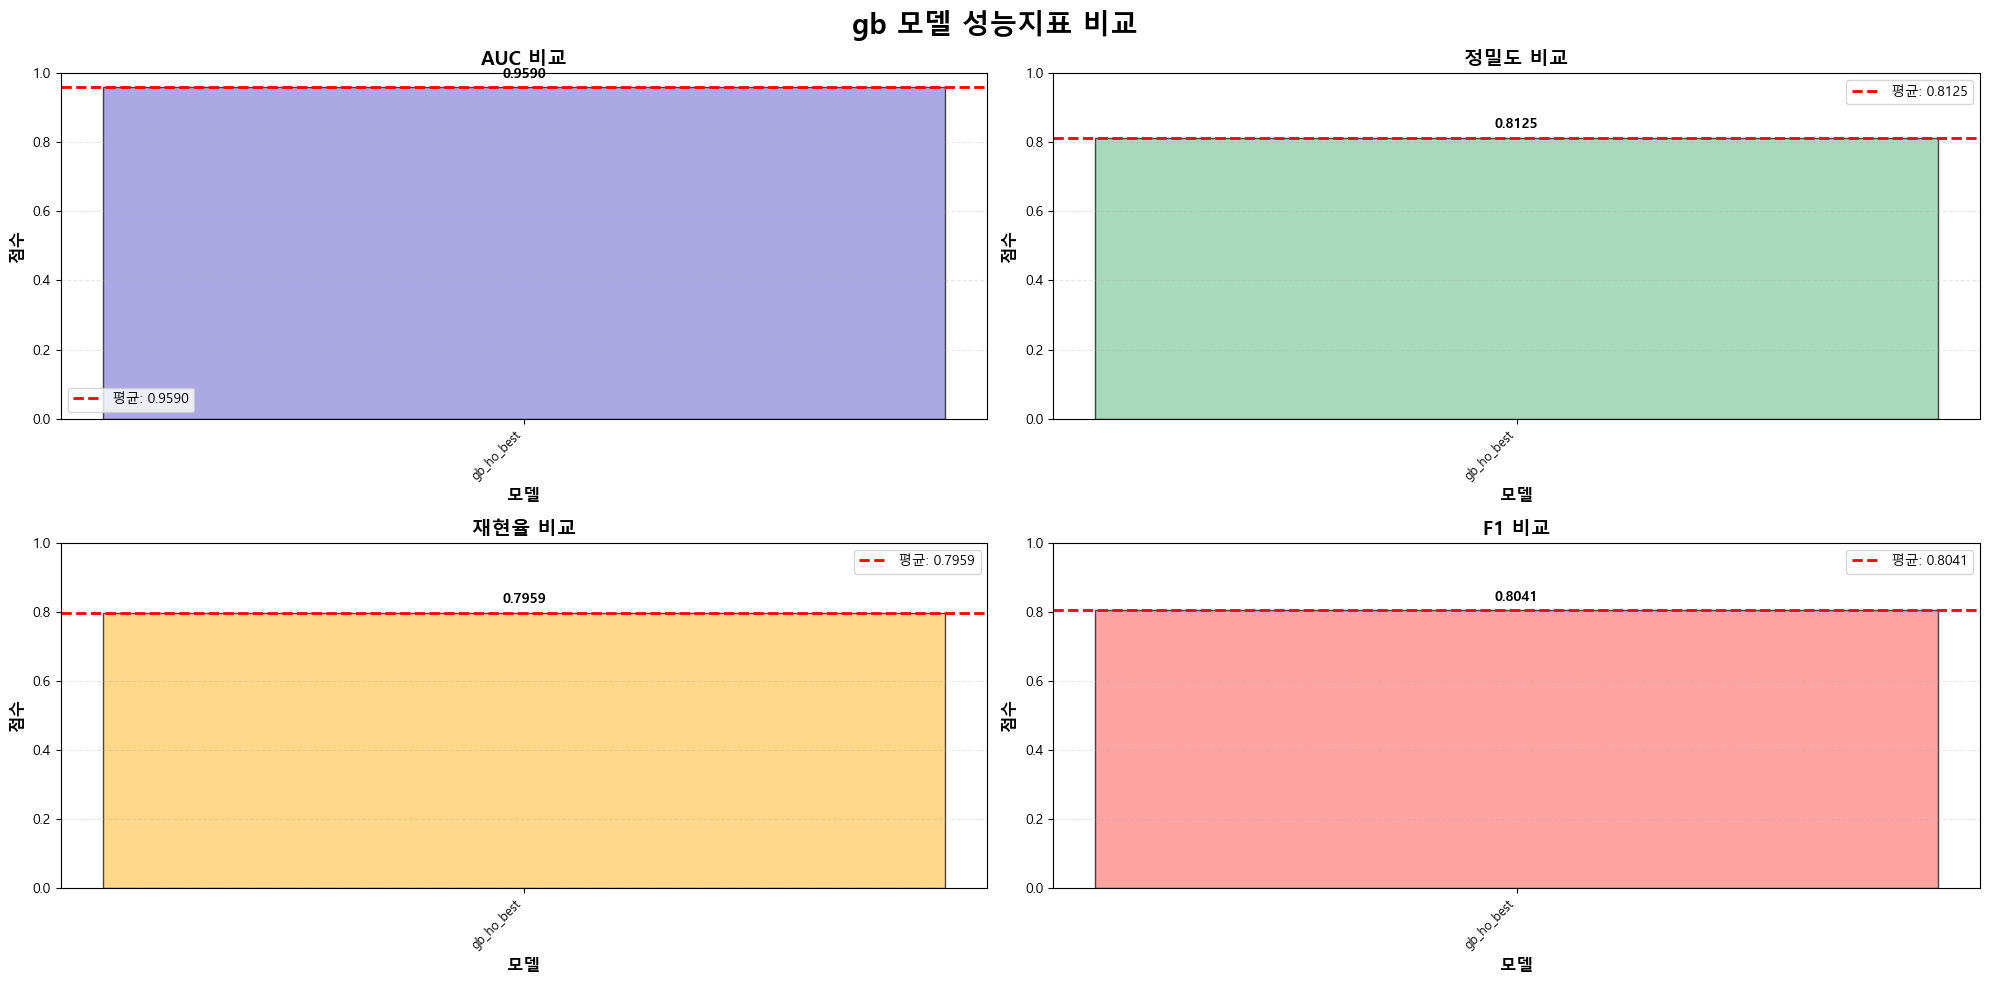


=== 지표별 통계 요약 ===

[AUC]
  최고: 0.9590 (gb_ho_best)
  최저: 0.9590 (gb_ho_best)
  평균: 0.9590
  표준편차: nan

[정밀도]
  최고: 0.8125 (gb_ho_best)
  최저: 0.8125 (gb_ho_best)
  평균: 0.8125
  표준편차: nan

[재현율]
  최고: 0.7959 (gb_ho_best)
  최저: 0.7959 (gb_ho_best)
  평균: 0.7959
  표준편차: nan

[F1]
  최고: 0.8041 (gb_ho_best)
  최저: 0.8041 (gb_ho_best)
  평균: 0.8041
  표준편차: nan


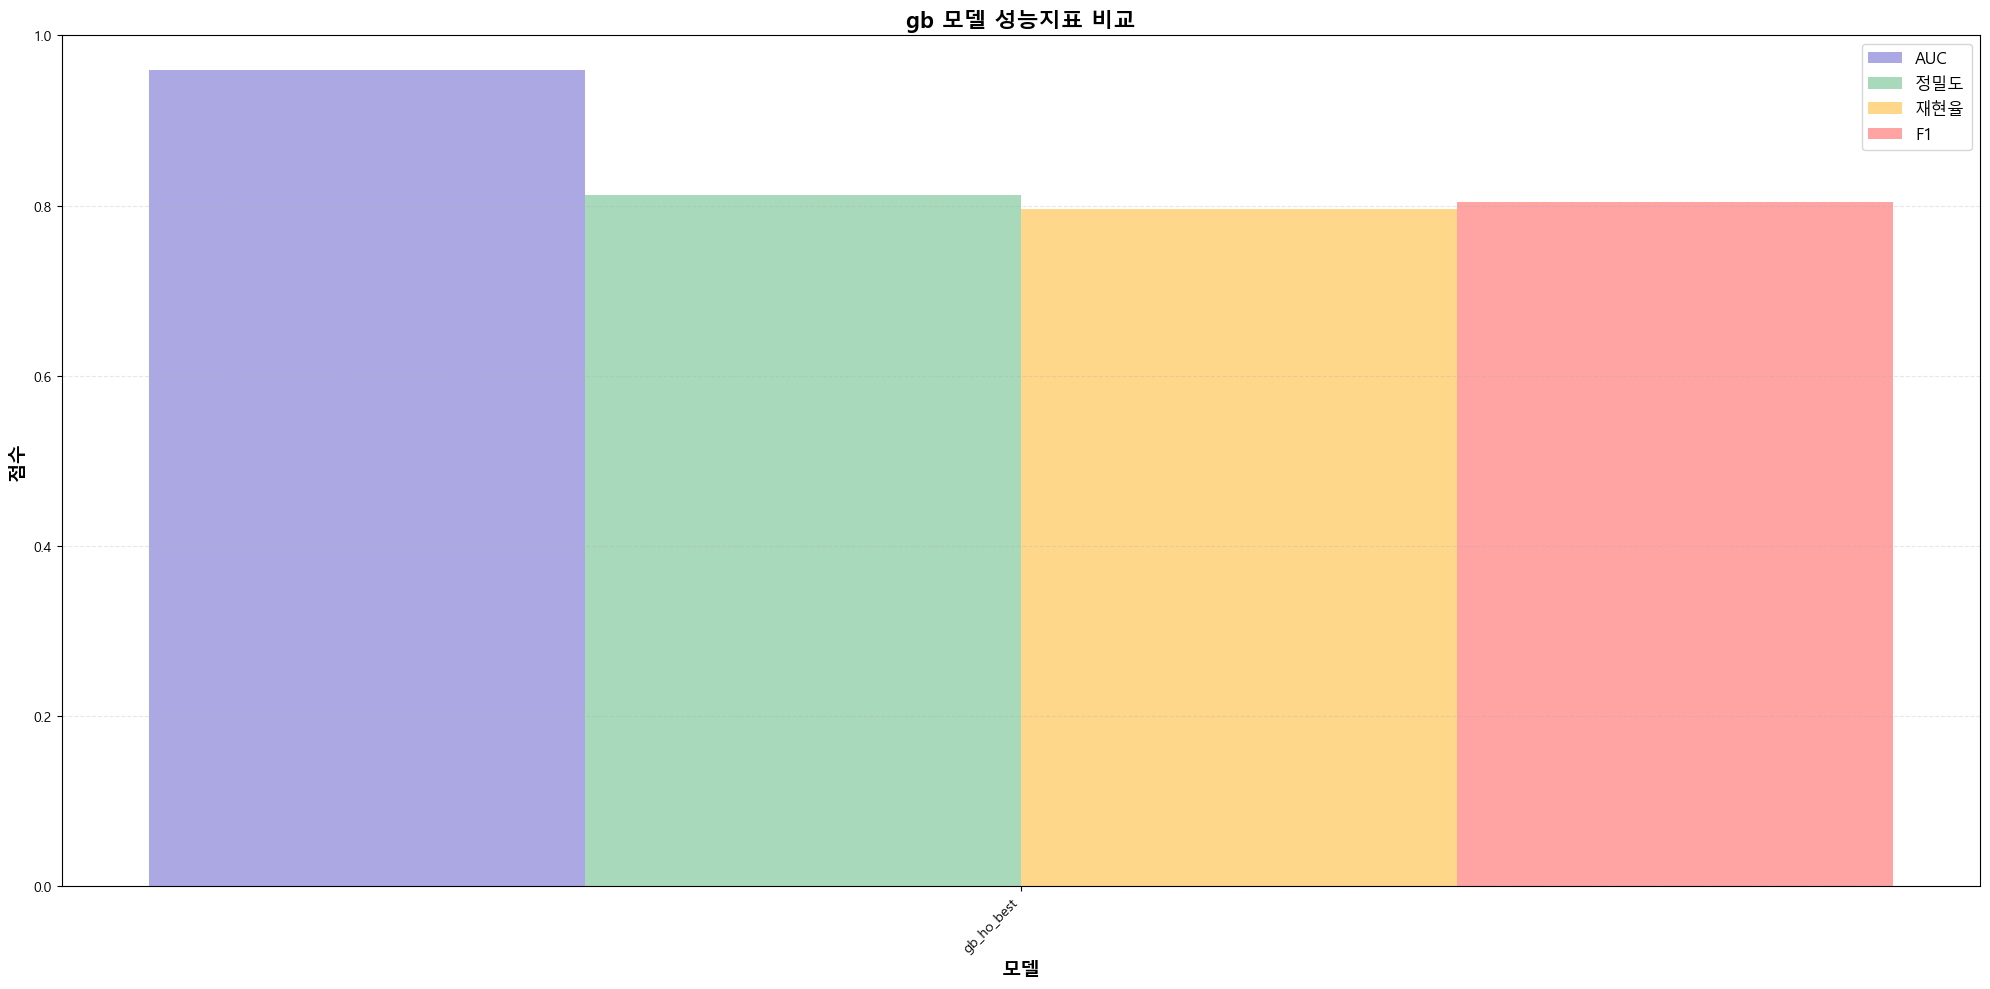


=== F1 Score 기준 상위 5개 모델 ===
              AUC     정밀도     재현율      F1
gb_ho_best  0.959  0.8125  0.7959  0.8041

그래프가 저장되었습니다: ../images/gb_모델_성능지표_비교_2025_1129.png


In [15]:
# 7 시각화
mo.model_metrics_graph(results, 'gb 모델 성능지표 비교')